In [1]:
%load_ext autoreload
%autoreload 2

import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
# from get_radial_profiles_new import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

%load_ext autoreload
%autoreload 2


/tmp/ipykernel_318874/3135684675.py:13: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# generate code to call get_xi

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
# merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
halo_params_dict['lg10_Mmin']  = 10.0
halo_params_dict['lg10_Mmax']  = 15.5
halo_params_dict['nM'] = 42


from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]

nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

df_nz_comoving = np.loadtxt(abs_path_data + '/pge/desi_lrg_comoving_density.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 10.0, 11000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True


/tmp/ipykernel_318874/916296665.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


In [3]:
sim_params_dict.keys()


dict_keys(['cosmo', 'init_power', 'nfw_trunc', 'epsilon_rt', 'theta_ej_0', 'log10_Mstar0_theta_ej', 'nu_theta_ej_M', 'nu_theta_ej_z', 'theta_co_0', 'log10_Mstar0_theta_co', 'nu_theta_co_M', 'nu_theta_co_z', 'mu_beta', 'log10_Mstar0', 'log10_Mc0', 'nu_z', 'nu_M', 'gamma_rhogas', 'delta_rhogas', 'a_zeta', 'n_zeta', 'alpha_nt', 'beta_nt', 'n_nt', 'log10M1_fshmr', 'log10M1_a_fshmr', 'log10Mstar0_fshmr', 'log10Mstar0_a_fshmr', 'beta_fshmr', 'beta_a_fshmr', 'delta_fshmr', 'delta_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat', 'Bcut_Nsat', 'Bsat_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'eta_star', 'eta_cga', 'A_starcga', 'log10_M1_starcga'])

In [4]:
import copy
import time 
from mcfitjax.cosmology_jax import xi2P
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg
analysis_dict_copy = copy.deepcopy(analysis_dict)
# analysis_dict_copy['symbolic_pk'] = True
# analysis_dict_copy['symbolic_hmf'] = True
analysis_dict_copy['verbose_time'] = False

sim_params_dict_copy = copy.deepcopy(sim_params_dict)

sim_params_dict_copy['theta_ej_0'] = 2.0
sim_params_dict_copy['nu_theta_ej_M'] = -0.1
sim_params_dict_copy['mu_beta'] = 0.05
sim_params_dict_copy['delta_rhogas'] = 8.0
sim_params_dict_copy['gamma_rhogas'] = 1.5
sim_params_dict_copy['theta_co_0'] = 0.3

base_test_symb = base_class(sim_params_dict_copy, halo_params_dict, analysis_dict_copy, other_params_dict)
profiles_test_symb = Profiles(sim_params_dict_copy, halo_params_dict, analysis_dict_copy, other_params_dict, base_class_obj=base_test_symb)
Pkz_test_symb = get_Pkz(sim_params_dict_copy, halo_params_dict, analysis_dict_copy, other_params_dict, Profiles_obj=profiles_test_symb)

vmapped_func = get_vmapped_func_warg(Pkz_test_symb.get_P_1h, 2, 4)
Pee_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test_symb.nk), jnp.arange(Pkz_test_symb.nz), 4, 4).T
# be_2h_kz_mat = Pkz_test_symb.be_kz_mat + Pkz_test_symb.bm_largescales_2h_mat_lt_Mmin
be_2h_kz_mat = Pkz_test_symb.be_kz_mat
Pee_2h_kz_mat = be_2h_kz_mat * be_2h_kz_mat * Pkz_test_symb.plin_kz_mat
Pee_tot_kz_mat = Pee_1h_kz_mat + Pee_2h_kz_mat




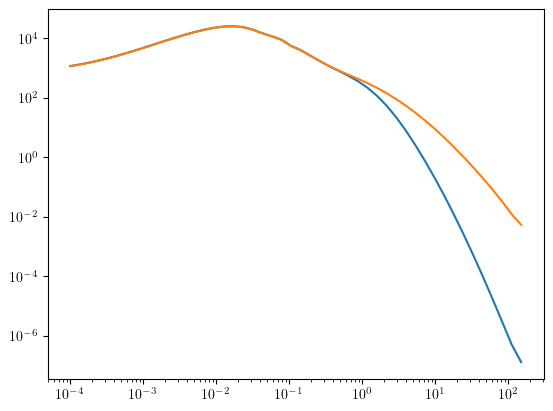

In [5]:
pl.figure()
pl.plot(Pkz_test_symb.kPk_array, Pee_tot_kz_mat[:,0], label='1h')
# pl.plot(Pkz_test_symb.kPk_array, Pkz_test_symb.phfit_kz_mat[:,0], label='1h')
pl.plot(Pkz_test_symb.kPk_array, Pkz_test_symb.Pmm_nfw_tot_mat[:,0], label='1h')
pl.xscale('log')
pl.yscale('log')




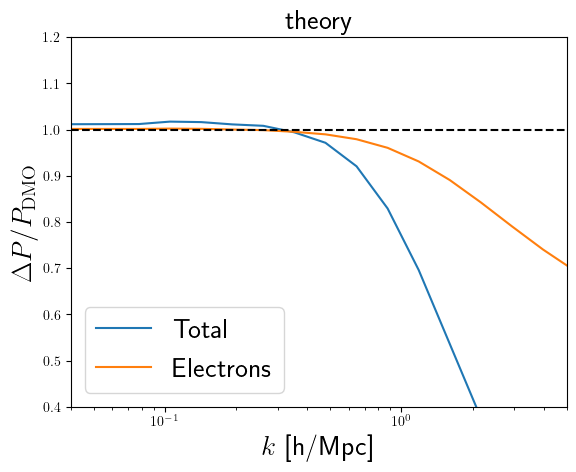

In [6]:
pl.figure()
pl.plot(Pkz_test_symb.kPk_array, Pee_tot_kz_mat[:,0]/Pkz_test_symb.Pmm_nfw_tot_mat[:,0], label='Total')
pl.plot(Pkz_test_symb.kPk_array, Pkz_test_symb.Pmm_dmb_tot_mat[:,0]/Pkz_test_symb.Pmm_nfw_tot_mat[:,0], label='Electrons')
# pl.plot(Pkz_test_symb.kPk_array, Pee_2h_kz_mat[:,0]/Pkz_test_symb.phfit_kz_mat[:,0], label='1h')
# pl.plot(Pkz_test_symb.kPk_array, Pkz_test_symb.phfit_kz_mat[:,0], label='1h')
pl.xscale('log')
pl.ylabel(r'$\Delta P/P_{\rm DMO}$', fontsize=20)
pl.xlabel(r'$k$ [h/Mpc]', fontsize=20)
pl.axhline(1.0, color='k', linestyle='--')
pl.xlim(4e-2, 5)
pl.ylim(0.4, 1.2)
pl.title('theory', fontsize=20)
pl.legend(fontsize=20)
# pl.yscale('log')


In [104]:
# self.k_mcfit, uk_ne = xi2P_obj(self.ne_mat / self.ne_mat_norm[-1, :, :][None, :, :], axis=0, extrap=False)
# self.uk_ne_tointp = jnp.array(uk_ne)


